# GNN — TSP Benchmark

Standard TSP (no time windows, no perturbations).  
Compares the trained **GNN** against classical baselines.

| Section | Content |
|---------|--------|
| 1 | Imports & model loading |
| 2 | Baseline helpers (NN, 2-opt, brute-force optimal) |
| 3 | Benchmark n=10 — comparison with optimal |
| 4 | Benchmark n=50, n=100 |
| 5 | Results table + inference time |
| 6 | Tour visualisation |

## Section 1 — Imports & model loading

Train first if the checkpoint does not exist:
```bash
python train.py --mode tsp --n 10 --epochs 3000 --size small
python train.py --mode tsp --n 50 --epochs 3000 --size medium
```

In [12]:
import sys, os, time
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import permutations

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from data  import random_instance, nn_tour_labels, two_opt_improve, tour_length, greedy_decode, optimal_tour_labels
from model import TSPGNN, MODEL_SIZES

torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cpu


In [13]:
SIZE = 'medium'          # 'small' | 'medium' | 'large'
d, L = MODEL_SIZES[SIZE]

# TSP model: node_dim=2 (x,y), edge_dim=1 (euclidean distance only)
model_tsp = TSPGNN(d=d, L=L, node_dim=2, edge_dim=1).to(DEVICE)

ckpt = f'model/gnn_{SIZE}.pt'
if os.path.exists(ckpt):
    model_tsp.load_state_dict(torch.load(ckpt, map_location='cpu'))
    print(f'Loaded {ckpt}')
else:
    print(f'WARNING: {ckpt} not found — using random weights (results meaningless)')

model_tsp.eval()
print(f'Parameters: {sum(p.numel() for p in model_tsp.parameters()):,}')

Loaded model/gnn_medium.pt
Parameters: 504,327


## Section 2 — Baseline helpers

In [14]:
def optimal_tour(coords: torch.Tensor):
    """Brute-force optimal tour — only feasible for n <= 10."""
    n = coords.shape[0]
    best_len, best_tour = float('inf'), None
    for perm in permutations(range(1, n)):
        t = [0] + list(perm)
        l = tour_length(coords, t)
        if l < best_len:
            best_len, best_tour = l, t
    return best_tour, best_len


def run_nn(coords: torch.Tensor) -> list:
    """Nearest-neighbour greedy tour."""
    dist = torch.cdist(coords, coords)
    p = 1.0 / (dist + 1e-8)
    p.fill_diagonal_(0.0)
    return greedy_decode(p, start=0)


def run_2opt(coords: torch.Tensor) -> list:
    """NN + 2-opt improvement."""
    return two_opt_improve(coords, run_nn(coords))


def run_gnn(coords: torch.Tensor) -> list:
    """GNN single-pass greedy decode."""
    with torch.no_grad():
        p = model_tsp(coords.to(DEVICE)).cpu()
    return greedy_decode(p, start=0)


def run_gnn_2opt(coords: torch.Tensor) -> list:
    """GNN + 2-opt refinement."""
    return two_opt_improve(coords, run_gnn(coords))


def gap(length: float, opt_length: float) -> float:
    return (length / opt_length - 1.0) * 100.0

## Section 3 — Benchmark n=10 (with brute-force optimal)

For n=10, brute-force optimal is feasible (9! = 362 880 permutations).

In [15]:
N_TRIALS = 50
methods  = ['nn', '2opt', 'gnn', 'gnn_2opt', 'optimal']
results  = {k: [] for k in methods}
times    = {k: [] for k in methods if k != 'optimal'}

for seed in range(N_TRIALS):
    coords = random_instance(10, seed=seed)

    _, opt_len = optimal_tour(coords)
    results['optimal'].append(opt_len)

    for name, fn in [('nn', run_nn), ('2opt', run_2opt),
                     ('gnn', run_gnn), ('gnn_2opt', run_gnn_2opt)]:
        t0 = time.perf_counter()
        tour = fn(coords)
        times[name].append(time.perf_counter() - t0)
        results[name].append(tour_length(coords, tour))

opt_avg = np.mean(results['optimal'])
print(f'n=10  ({N_TRIALS} trials)')
print(f'{"Method":<15} {"Avg length":>12} {"Gap to opt":>12} {"Avg time (ms)":>15}')
print('-' * 57)
print(f'{"optimal":<15} {opt_avg:>12.4f} {"-":>12} {"-":>15}')
for m in ['nn', '2opt', 'gnn', 'gnn_2opt']:
    avg = np.mean(results[m])
    g   = gap(avg, opt_avg)
    t   = np.mean(times[m]) * 1000
    print(f'{m:<15} {avg:>12.4f} {g:>+11.1f}% {t:>14.1f}ms')

n=10  (50 trials)
Method            Avg length   Gap to opt   Avg time (ms)
---------------------------------------------------------
optimal               2.7703            -               -
nn                    3.0469       +10.0%            0.1ms
2opt                  2.7789        +0.3%            0.4ms
gnn                   3.6248       +30.8%            1.0ms
gnn_2opt              2.7903        +0.7%            1.1ms


## Section 4 — Benchmark n=50, n=100

No brute-force optimal at this scale — gap is reported relative to NN baseline.

In [16]:
N_TRIALS_LARGE = 20
METHODS_LARGE  = ['nn', '2opt', 'gnn', 'gnn_2opt']

all_results = {}   # {n: {method: [lengths]}}
all_times   = {}   # {n: {method: [seconds]}}

for N in [50, 100]:
    res = {k: [] for k in METHODS_LARGE}
    tms = {k: [] for k in METHODS_LARGE}

    for seed in range(N_TRIALS_LARGE):
        coords = random_instance(N, seed=seed)
        for name, fn in [('nn', run_nn), ('2opt', run_2opt),
                         ('gnn', run_gnn), ('gnn_2opt', run_gnn_2opt)]:
            t0 = time.perf_counter()
            tour = fn(coords)
            tms[name].append(time.perf_counter() - t0)
            res[name].append(tour_length(coords, tour))

    all_results[N] = res
    all_times[N]   = tms

    nn_avg = np.mean(res['nn'])
    print(f'\nn={N}  ({N_TRIALS_LARGE} trials)  [gap vs NN baseline]')
    print(f'{"Method":<15} {"Avg length":>12} {"Gap vs NN":>12} {"Avg time (ms)":>15}')
    print('-' * 57)
    for m in METHODS_LARGE:
        avg = np.mean(res[m])
        g   = gap(avg, nn_avg)
        t   = np.mean(tms[m]) * 1000
        print(f'{m:<15} {avg:>12.4f} {g:>+11.1f}% {t:>14.1f}ms')


n=50  (20 trials)  [gap vs NN baseline]
Method            Avg length    Gap vs NN   Avg time (ms)
---------------------------------------------------------
nn                    7.1567        +0.0%            0.4ms
2opt                  6.0832       -15.0%           17.2ms
gnn                   8.6760       +21.2%            4.0ms
gnn_2opt              6.1679       -13.8%           25.2ms

n=100  (20 trials)  [gap vs NN baseline]
Method            Avg length    Gap vs NN   Avg time (ms)
---------------------------------------------------------
nn                    9.8126        +0.0%            0.6ms
2opt                  8.3997       -14.4%           86.4ms
gnn                  11.7107       +19.3%           10.8ms
gnn_2opt              8.3524       -14.9%          103.5ms


## Section 5 — Summary bar chart

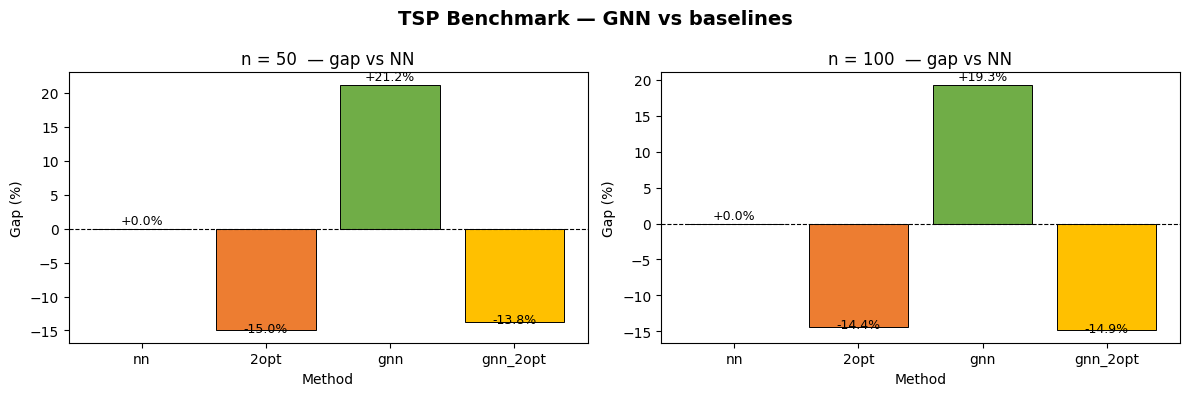

Saved figures/benchmark/tsp_gap_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'nn': '#5B9BD5', '2opt': '#ED7D31', 'gnn': '#70AD47', 'gnn_2opt': '#FFC000'}

for ax, N in zip(axes, [50, 100]):
    res    = all_results[N]
    nn_avg = np.mean(res['nn'])
    gaps   = {m: gap(np.mean(res[m]), nn_avg) for m in METHODS_LARGE}
    labels = list(gaps.keys())
    vals   = [gaps[m] for m in labels]
    bars   = ax.bar(labels, vals, color=[colors[m] for m in labels], edgecolor='black', linewidth=0.7)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'n = {N}  — gap vs NN', fontsize=12)
    ax.set_ylabel('Gap (%)') 
    ax.set_xlabel('Method')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + (0.2 if v >= 0 else -0.6),
                f'{v:+.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('TSP Benchmark — GNN vs baselines', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('figures/benchmark', exist_ok=True)
plt.savefig('figures/benchmark/tsp_gap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/benchmark/tsp_gap_comparison.png')

## Section 6 — Tour visualisation

Visual comparison of all methods on a single n=20 instance.

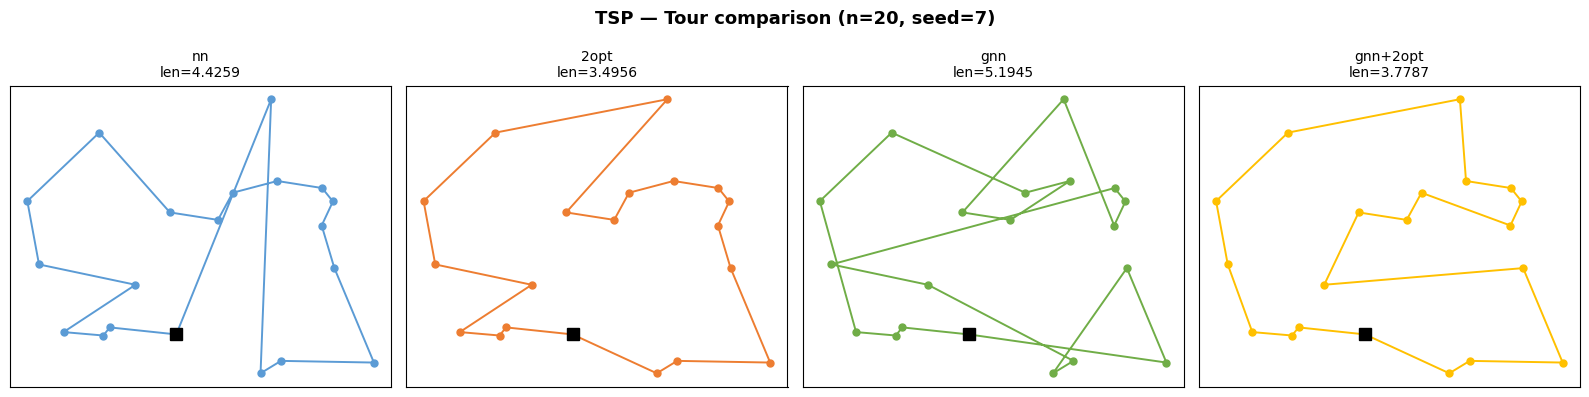

Saved figures/benchmark/tsp_tour_comparison.png


In [18]:
coords_viz = random_instance(20, seed=7)
tours = {
    'nn':      run_nn(coords_viz),
    '2opt':    run_2opt(coords_viz),
    'gnn':     run_gnn(coords_viz),
    'gnn+2opt': run_gnn_2opt(coords_viz),
}

def draw_tour(ax, coords, tour, color, title):
    xy = coords.numpy()
    closed = tour + [tour[0]]
    xs = xy[closed, 0]
    ys = xy[closed, 1]
    ax.plot(xs, ys, '-o', color=color, markersize=5, linewidth=1.4)
    ax.plot(xy[0, 0], xy[0, 1], 's', color='black', markersize=9, zorder=5, label='Depot')
    length = tour_length(coords, tour)
    ax.set_title(f'{title}\nlen={length:.4f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
palette = ['#5B9BD5', '#ED7D31', '#70AD47', '#FFC000']
for ax, (name, tour), color in zip(axes, tours.items(), palette):
    draw_tour(ax, coords_viz, tour, color, name)

plt.suptitle('TSP — Tour comparison (n=20, seed=7)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/benchmark/tsp_tour_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/benchmark/tsp_tour_comparison.png')

## Section 7 — Model overview figure

Four-panel overview on a seed-0, n=8 instance:
1. **BCE training loss curve** — from `model/losses.npy`
2. **Ground-truth edge matrix** $y_{ij}$ — brute-force optimal labels
3. **Predicted probabilities** $\hat{p}_{ij}$ — GNN forward pass
4. **Tour comparison** — optimal (green) vs GNN greedy (blue)

Saved to `figures/demo_overview.png` (referenced in the technical report).

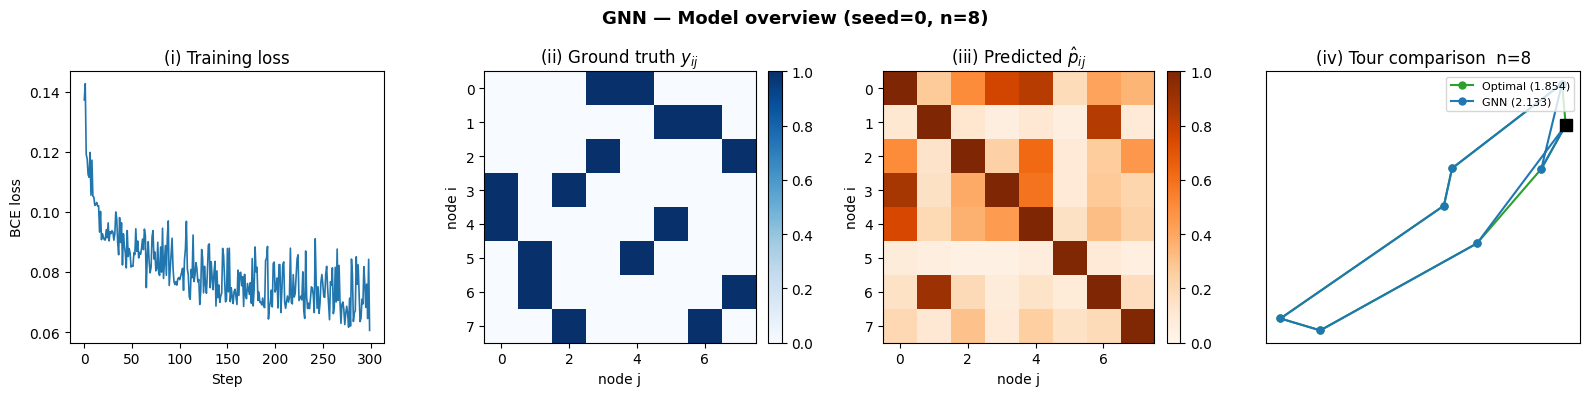

Saved figures/demo_overview.png


In [19]:
# ── Section 7: demo_overview.png ──────────────────────────────────────────────
# Requires: model/gnn_{SIZE}.pt  (loaded in Section 1)
#           model/losses.npy     (saved automatically by train.py alongside weights)

DEMO_N    = 8
DEMO_SEED = 0

coords_demo = random_instance(DEMO_N, seed=DEMO_SEED)

# Panel (ii): ground-truth labels (brute-force optimal for n=8)
y_labels = optimal_tour_labels(coords_demo)   # (n, n) float tensor

# Panel (iii): GNN predicted probabilities
with torch.no_grad():
    p_hat = model_tsp(coords_demo.to(DEVICE)).cpu()   # (n, n)

# Panel (iv): tours
opt_t, opt_len = optimal_tour(coords_demo)
gnn_tour       = greedy_decode(p_hat, start=0)
gnn_len        = tour_length(coords_demo, gnn_tour)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# (i) Loss curve
ax = axes[0]
losses_path = 'model/losses.npy'
if os.path.exists(losses_path):
    losses_arr = np.load(losses_path)
    ax.plot(losses_arr, linewidth=1.2, color='#2176AE')
    ax.set_xlabel('Step')
    ax.set_ylabel('BCE loss')
    ax.set_title('(i) Training loss')
else:
    ax.text(0.5, 0.5, 'losses.npy not found\n(run train.py first)',
            ha='center', va='center', transform=ax.transAxes, fontsize=9,
            color='grey')
    ax.set_title('(i) Training loss')
    ax.set_xticks([]); ax.set_yticks([])

# (ii) Ground-truth edge matrix
ax = axes[1]
im = ax.imshow(y_labels.numpy(), cmap='Blues', vmin=0, vmax=1)
ax.set_title(r'(ii) Ground truth $y_{ij}$')
ax.set_xlabel('node j'); ax.set_ylabel('node i')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# (iii) Predicted probabilities
ax = axes[2]
im2 = ax.imshow(p_hat.numpy(), cmap='Oranges', vmin=0, vmax=1)
ax.set_title(r'(iii) Predicted $\hat{p}_{ij}$')
ax.set_xlabel('node j'); ax.set_ylabel('node i')
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# (iv) Tour comparison
ax = axes[3]
xy = coords_demo.numpy()

def _plot_tour(ax, xy, tour, color, label):
    closed = tour + [tour[0]]
    ax.plot(xy[closed, 0], xy[closed, 1], '-o', color=color,
            markersize=5, linewidth=1.5, label=label)

_plot_tour(ax, xy, opt_t,    '#2CA02C', f'Optimal ({opt_len:.3f})')
_plot_tour(ax, xy, gnn_tour, '#1F77B4', f'GNN ({gnn_len:.3f})')
ax.plot(xy[0, 0], xy[0, 1], 's', color='black', markersize=9, zorder=5)
ax.set_title(f'(iv) Tour comparison  n={DEMO_N}')
ax.legend(fontsize=8, loc='upper right')
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('GNN — Model overview (seed=0, n=8)', fontsize=13, fontweight='bold')
plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/demo_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/demo_overview.png')